# 📺 Netflix Content Analysis
### Exploratory Data Analysis & Interactive Dashboard

This notebook analyzes the Netflix Titles dataset (movies & TV shows added to Netflix through 2021, ~7,800 titles).
We'll explore content trends, genres, countries, ratings, and durations, then build an interactive dashboard at the end.

**Dataset source:** Public Netflix Titles dataset (TidyTuesday / Kaggle), `netflix_titles.csv`

**Contents**
1. Setup & Data Loading
2. Data Cleaning
3. Content Type Analysis (Movies vs TV Shows)
4. Trends Over Time
5. Genre Analysis
6. Geographic Analysis
7. Ratings & Duration Analysis
8. Interactive Dashboard (Plotly)
9. Key Insights Summary


In [32]:
# Install/import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
NETFLIX_RED = '#E50914'
NETFLIX_DARK = '#221F1F'
palette = [NETFLIX_RED, '#B81D24', '#831010', '#F5F5F1', '#564d4d']

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [33]:
# Load the dataset
import pandas as pd
df = pd.read_csv(r"C:\Users\dell\OneDrive\Desktop\Pandas\Netflix-Analysis\netflix_titles.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 7787 rows, 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [34]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [35]:
# Missing values overview
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
director,2389,30.68
cast,718,9.22
country,507,6.51
date_added,10,0.13
rating,7,0.09
title,0,0.00
show_id,0,0.00
type,0,0.00
release_year,0,0.00
duration,0,0.00


## 2. Data Cleaning

We'll handle missing values, parse dates, and engineer useful features (year added, month added, duration in numeric form, primary country, primary genre).

In [36]:
# Fill missing categorical fields
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Parse date_added
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Split duration into numeric value + unit (mins for movies, seasons for TV shows)
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].apply(lambda x: 'min' if 'min' in str(x) else 'Season(s)')

# Primary (first-listed) country and genre for simpler grouping
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0].strip())

print("Cleaning complete ✅")
df[['type','country','primary_country','listed_in','primary_genre','duration','duration_int','duration_unit','year_added']].head()

Cleaning complete ✅


,type,country,primary_country,listed_in,primary_genre,duration,duration_int,duration_unit,year_added
0,TV Show,Brazil,Brazil,"International TV Shows, TV Dramas, TV Sci-Fi &...",International TV Shows,4 Seasons,4.0,Season(s),2020.0
1,Movie,Mexico,Mexico,"Dramas, International Movies",Dramas,93 min,93.0,min,2016.0
2,Movie,Singapore,Singapore,"Horror Movies, International Movies",Horror Movies,78 min,78.0,min,2018.0
3,Movie,United States,United States,"Action & Adventure, Independent Movies, Sci-Fi...",Action & Adventure,80 min,80.0,min,2017.0
4,Movie,United States,United States,Dramas,Dramas,123 min,123.0,min,2020.0


## 3. Content Type: Movies vs TV Shows

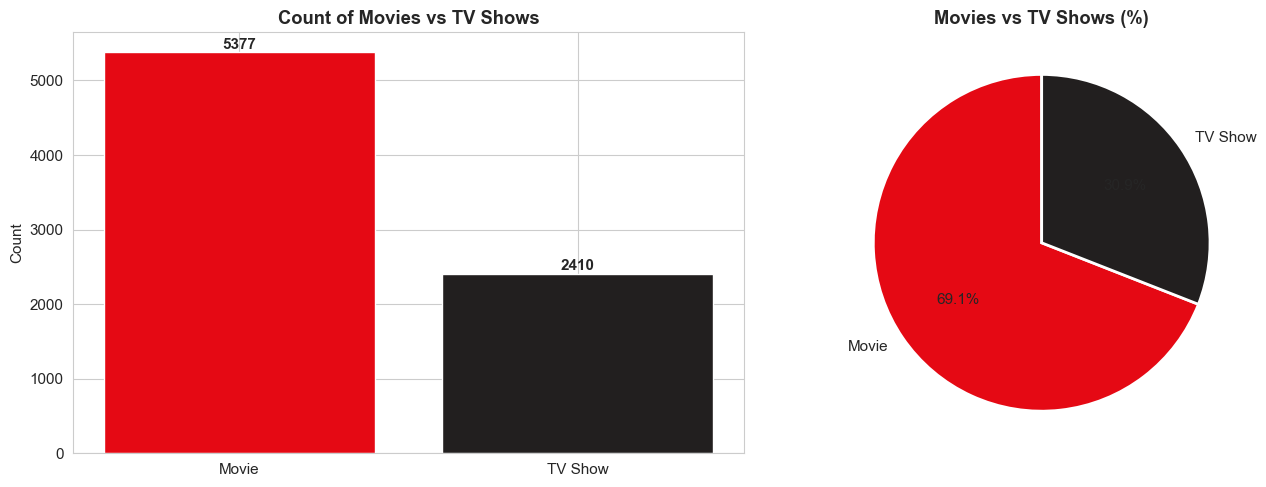

Movies: 5377 (69.1%)
TV Shows: 2410 (30.9%)


In [37]:
type_counts = df['type'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(type_counts.index, type_counts.values, color=[NETFLIX_RED, NETFLIX_DARK])
axes[0].set_title('Count of Movies vs TV Shows', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=[NETFLIX_RED, NETFLIX_DARK], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Movies vs TV Shows (%)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Movies: {type_counts.get('Movie',0)} ({type_counts.get('Movie',0)/len(df)*100:.1f}%)")
print(f"TV Shows: {type_counts.get('TV Show',0)} ({type_counts.get('TV Show',0)/len(df)*100:.1f}%)")

## 4. Trends Over Time

How has Netflix's content library grown, and when was content originally released vs added to the platform?

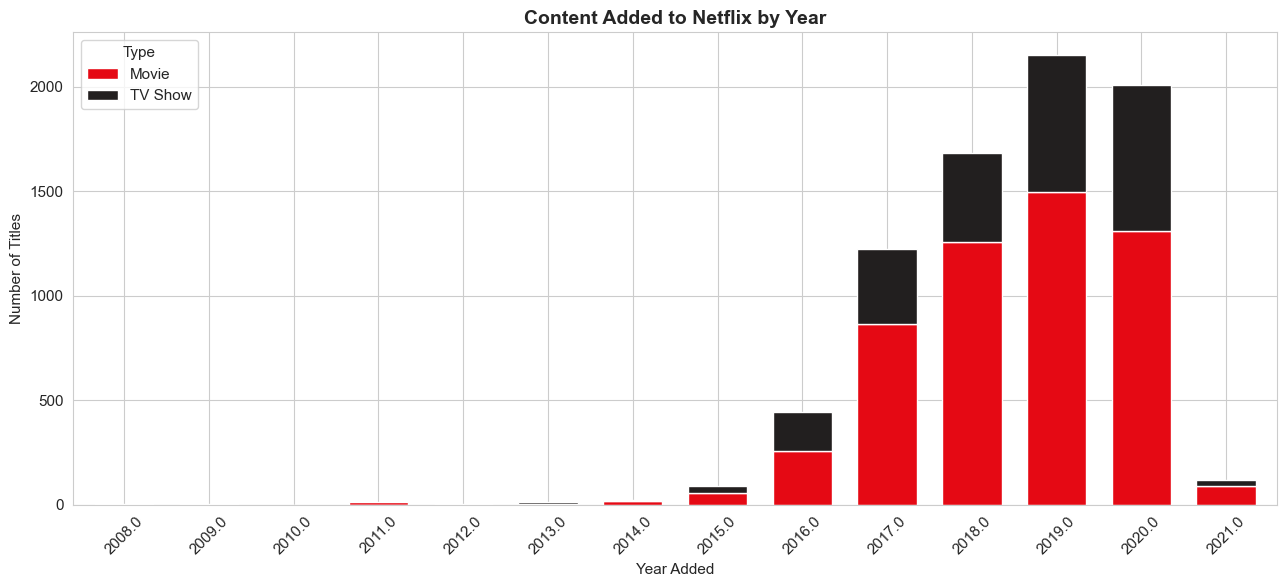

In [38]:
# Content added per year (platform growth)
added_by_year = df.dropna(subset=['year_added']).groupby(['year_added','type']).size().unstack(fill_value=0)
added_by_year = added_by_year[added_by_year.index <= 2021]  # dataset coverage

fig, ax = plt.subplots(figsize=(13,6))
added_by_year.plot(kind='bar', stacked=True, ax=ax, color=[NETFLIX_RED, NETFLIX_DARK], width=0.7)
ax.set_title('Content Added to Netflix by Year', fontweight='bold', fontsize=14)
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
ax.legend(title='Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

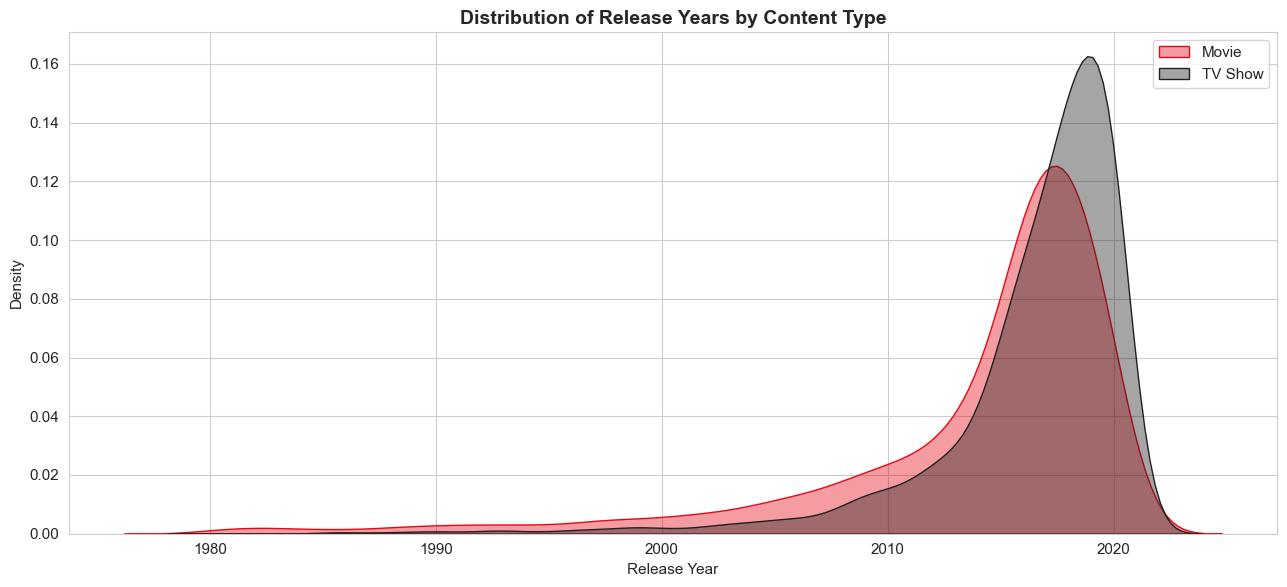

In [39]:
# Release year distribution
fig, ax = plt.subplots(figsize=(13,6))
for t, color in zip(['Movie','TV Show'], [NETFLIX_RED, NETFLIX_DARK]):
    subset = df[(df['type']==t) & (df['release_year'] >= 1980)]
    sns.kdeplot(subset['release_year'], fill=True, alpha=0.4, label=t, color=color, ax=ax)
ax.set_title('Distribution of Release Years by Content Type', fontweight='bold', fontsize=14)
ax.set_xlabel('Release Year')
ax.legend()
plt.tight_layout()
plt.show()

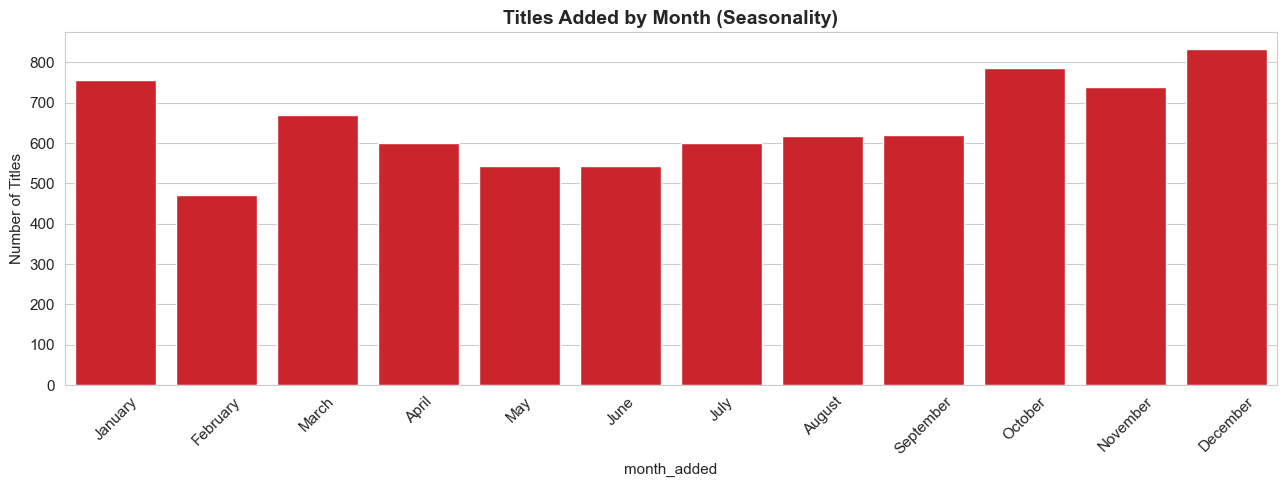

In [40]:
# Monthly seasonality of additions
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly = df['month_added'].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(13,5))
sns.barplot(x=monthly.index, y=monthly.values, color=NETFLIX_RED, ax=ax)
ax.set_title('Titles Added by Month (Seasonality)', fontweight='bold', fontsize=14)
ax.set_ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Genre Analysis

The `listed_in` column can contain multiple genres per title, so we explode it to count genre frequency.

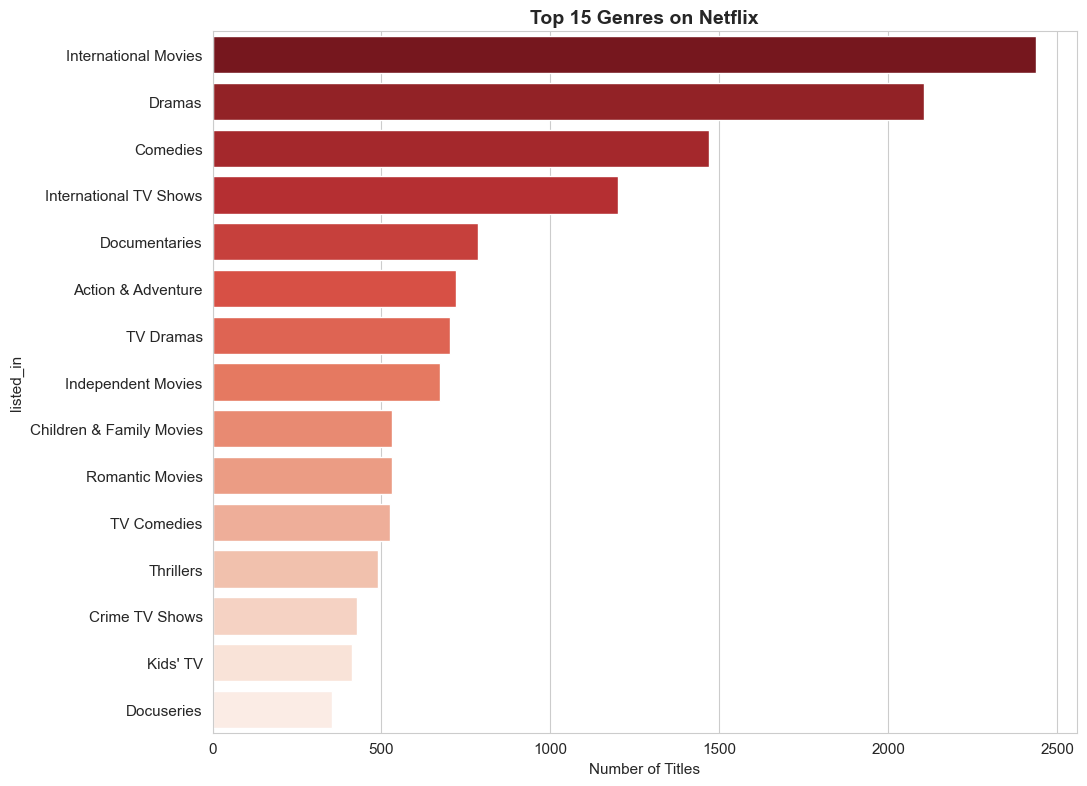

In [41]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(11,8))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r', ax=ax)
ax.set_title('Top 15 Genres on Netflix', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.show()

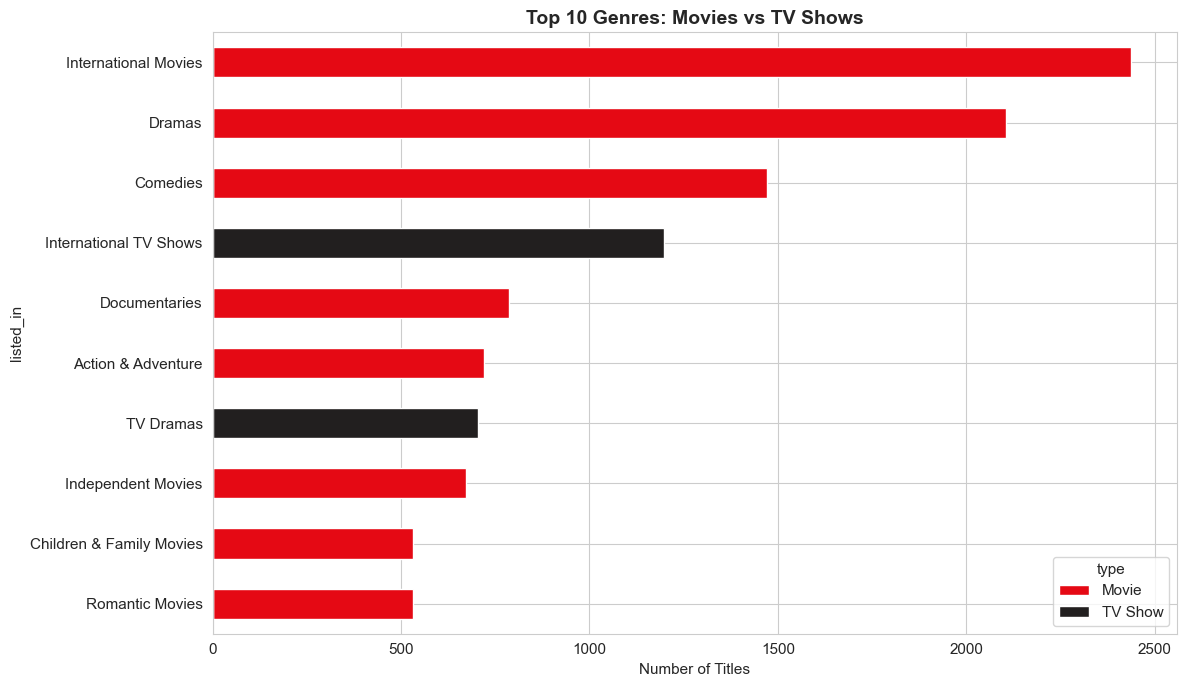

In [42]:
# Top genres split by content type
genre_type = df[['type','listed_in']].copy()
genre_type['listed_in'] = genre_type['listed_in'].str.split(', ')
genre_type = genre_type.explode('listed_in')
top_genre_list = top_genres.head(10).index
gt_pivot = genre_type[genre_type['listed_in'].isin(top_genre_list)].groupby(['listed_in','type']).size().unstack(fill_value=0)
gt_pivot = gt_pivot.loc[top_genre_list]

fig, ax = plt.subplots(figsize=(12,7))
gt_pivot.plot(kind='barh', stacked=True, color=[NETFLIX_RED, NETFLIX_DARK], ax=ax)
ax.set_title('Top 10 Genres: Movies vs TV Shows', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Titles')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Geographic Analysis

Which countries produce the most Netflix content?

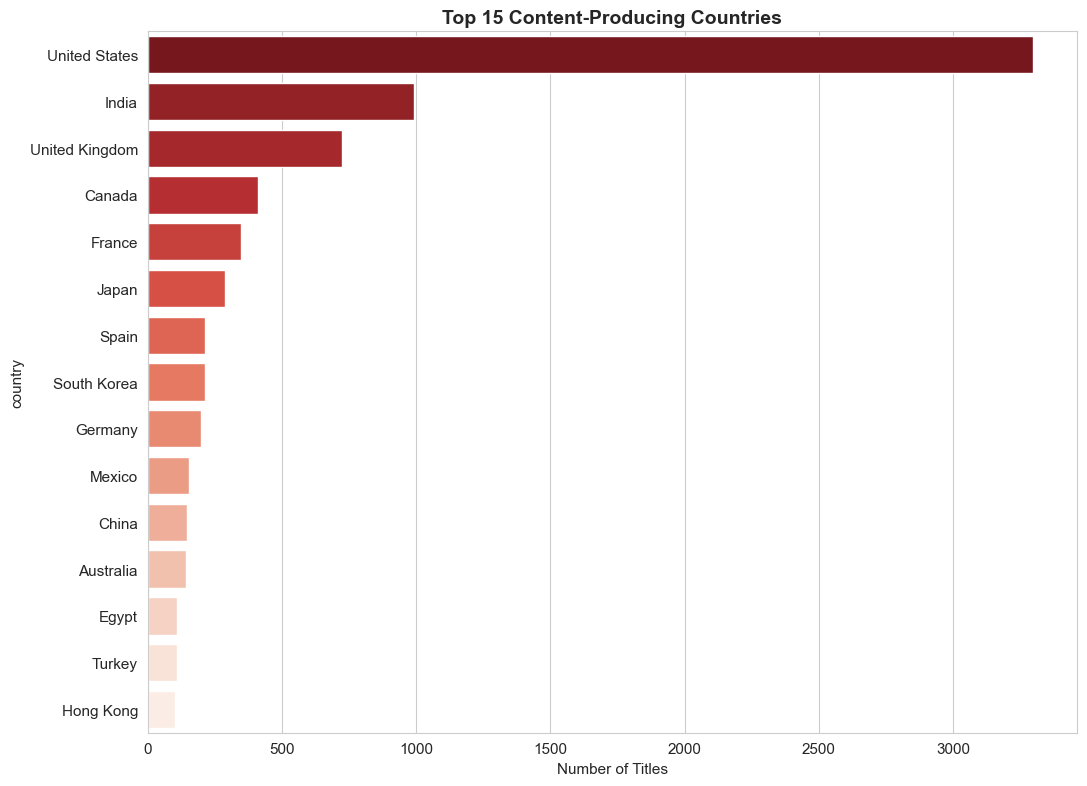

In [43]:
countries = df['country'].str.split(', ').explode()
countries = countries[countries != 'Unknown']
top_countries = countries.value_counts().head(15)

fig, ax = plt.subplots(figsize=(11,8))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r', ax=ax)
ax.set_title('Top 15 Content-Producing Countries', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.show()

In [44]:
# Choropleth map of content count by country
country_counts = countries.value_counts().reset_index()
country_counts.columns = ['country','count']

fig = px.choropleth(country_counts, locations='country', locationmode='country names',
                     color='count', color_continuous_scale='Reds',
                     title='Netflix Content Count by Country')
fig.update_layout(title_font_size=16, geo=dict(showframe=False, showcoastlines=False))
fig.show()

## 7. Ratings & Duration Analysis

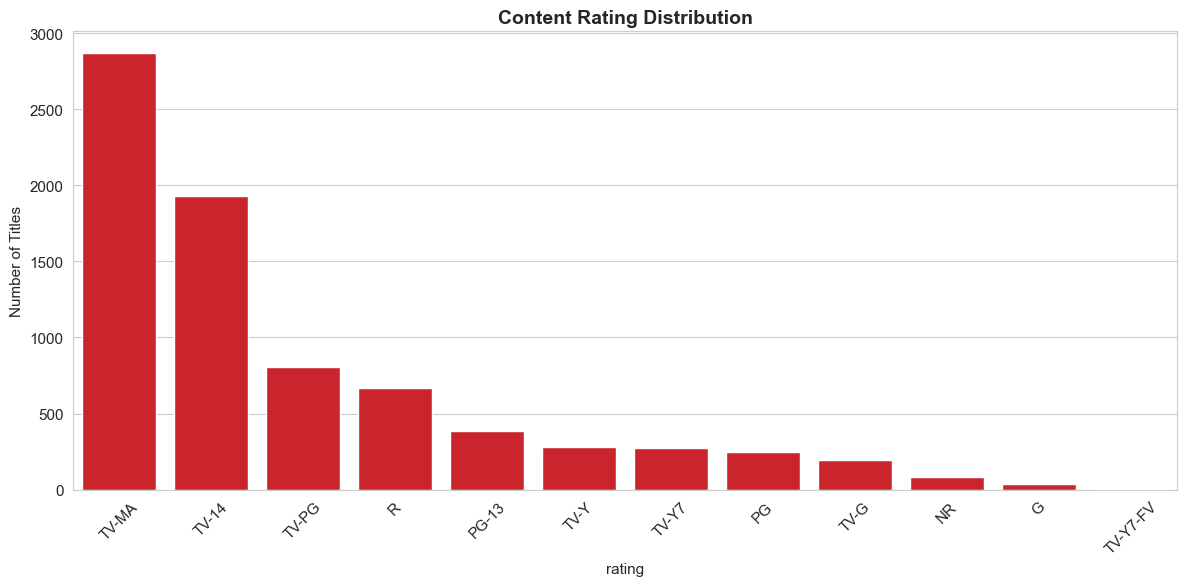

In [45]:
# Rating distribution
rating_counts = df['rating'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, color=NETFLIX_RED, ax=ax)
ax.set_title('Content Rating Distribution', fontweight='bold', fontsize=14)
ax.set_ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

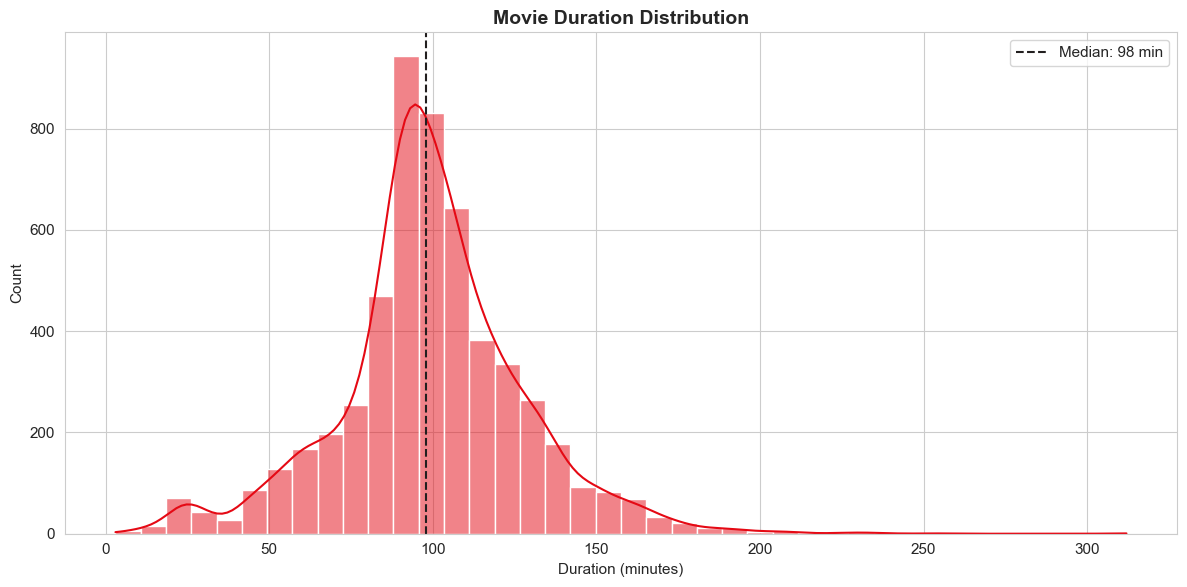

In [46]:
# Movie duration distribution
movies = df[df['type']=='Movie']
fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(movies['duration_int'].dropna(), bins=40, color=NETFLIX_RED, ax=ax, kde=True)
ax.axvline(movies['duration_int'].median(), color=NETFLIX_DARK, linestyle='--', label=f"Median: {movies['duration_int'].median():.0f} min")
ax.set_title('Movie Duration Distribution', fontweight='bold', fontsize=14)
ax.set_xlabel('Duration (minutes)')
ax.legend()
plt.tight_layout()
plt.show()

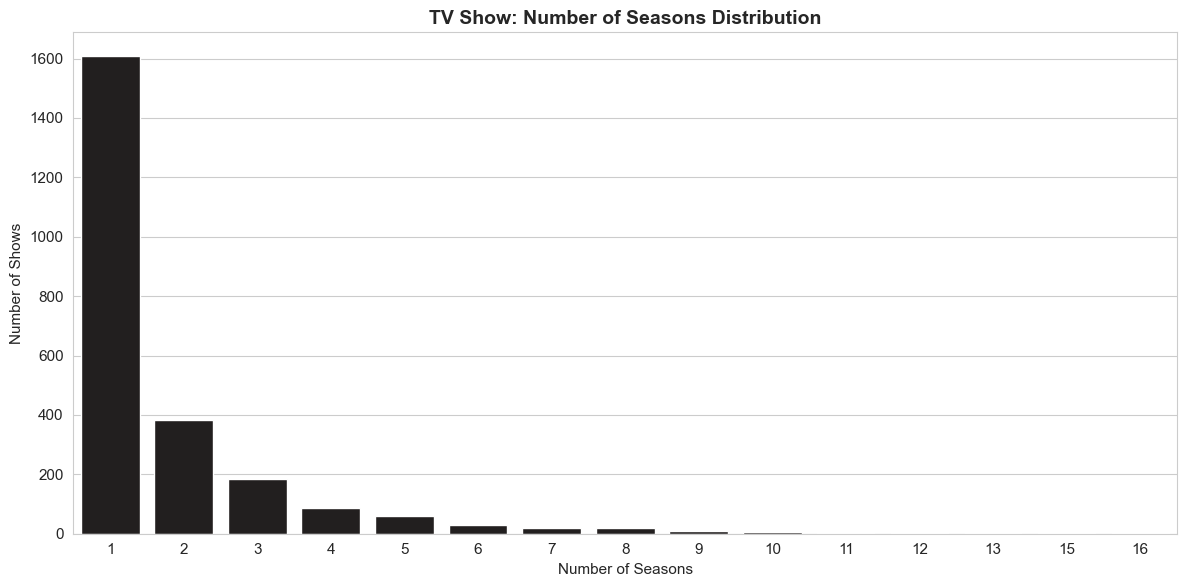

In [47]:
# TV show seasons distribution
tv = df[df['type']=='TV Show']
season_counts = tv['duration_int'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=season_counts.index.astype(int), y=season_counts.values, color=NETFLIX_DARK, ax=ax)
ax.set_title('TV Show: Number of Seasons Distribution', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Seasons')
ax.set_ylabel('Number of Shows')
plt.tight_layout()
plt.show()

## 8. Interactive Dashboard (Plotly)

A combined interactive dashboard summarizing the key metrics above — hover over charts to explore the data.

In [48]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Content Added by Year', 'Top 10 Genres', 'Top 10 Countries', 'Rating Distribution'),
    specs=[[{"type":"bar"}, {"type":"bar"}],
           [{"type":"bar"}, {"type":"pie"}]]
)

# 1. Content added by year
yearly = df.dropna(subset=['year_added'])
yearly = yearly[yearly['year_added'] <= 2021].groupby('year_added').size()
fig.add_trace(go.Bar(x=yearly.index.astype(int), y=yearly.values, marker_color=NETFLIX_RED, name='Titles Added'), row=1, col=1)

# 2. Top genres
tg = top_genres.head(10)
fig.add_trace(go.Bar(x=tg.values, y=tg.index, orientation='h', marker_color=NETFLIX_RED, name='Genres'), row=1, col=2)

# 3. Top countries
tc = top_countries.head(10)
fig.add_trace(go.Bar(x=tc.index, y=tc.values, marker_color=NETFLIX_DARK, name='Countries'), row=2, col=1)

# 4. Rating pie
rc = df['rating'].value_counts().head(7)
fig.add_trace(go.Pie(labels=rc.index, values=rc.values, marker_colors=px.colors.sequential.Reds_r), row=2, col=2)

fig.update_layout(
    height=850, width=1100,
    title_text="📺 Netflix Content Analysis — Interactive Dashboard",
    title_font_size=20,
    showlegend=False,
    template='plotly_white'
)
fig.update_xaxes(tickangle=45, row=2, col=1)
fig.show()

In [49]:
# Bonus: interactive treemap of genre x type
treemap_df = genre_type[genre_type['listed_in'].isin(genres.value_counts().head(20).index)]
treemap_counts = treemap_df.groupby(['type','listed_in']).size().reset_index(name='count')

fig2 = px.treemap(treemap_counts, path=['type','listed_in'], values='count',
                   color='count', color_continuous_scale='Reds',
                   title='Genre Breakdown by Content Type (Treemap)')
fig2.update_layout(height=600, title_font_size=16)
fig2.show()

## 9. Key Insights Summary

Run the cell below to auto-generate a text summary of the main findings from this analysis.

In [50]:
print("="*60)
print("📺 NETFLIX CONTENT ANALYSIS — KEY INSIGHTS")
print("="*60)

print(f"\n1. CONTENT MIX: {type_counts.get('Movie',0)} Movies ({type_counts.get('Movie',0)/len(df)*100:.1f}%) vs "
      f"{type_counts.get('TV Show',0)} TV Shows ({type_counts.get('TV Show',0)/len(df)*100:.1f}%)")

peak_year = added_by_year.sum(axis=1).idxmax()
print(f"\n2. GROWTH: Peak content addition year was {int(peak_year)} with "
      f"{int(added_by_year.sum(axis=1).max())} titles added.")

print(f"\n3. TOP GENRE: '{top_genres.index[0]}' is the most common genre with {top_genres.iloc[0]} titles.")

print(f"\n4. TOP COUNTRY: '{top_countries.index[0]}' produces the most content with {top_countries.iloc[0]} titles.")

print(f"\n5. MOVIE LENGTH: Median movie duration is {movies['duration_int'].median():.0f} minutes.")

most_common_seasons = tv['duration_int'].mode()[0]
print(f"\n6. TV SHOWS: Most TV shows have only {int(most_common_seasons)} season "
      f"({(tv['duration_int']==most_common_seasons).sum()} shows / {(tv['duration_int']==most_common_seasons).sum()/len(tv)*100:.1f}%).")

print(f"\n7. TOP RATING: '{rating_counts.index[0]}' is the most common content rating ({rating_counts.iloc[0]} titles).")

print("\n" + "="*60)

📺 NETFLIX CONTENT ANALYSIS — KEY INSIGHTS

1. CONTENT MIX: 5377 Movies (69.1%) vs 2410 TV Shows (30.9%)

2. GROWTH: Peak content addition year was 2019 with 2153 titles added.

3. TOP GENRE: 'International Movies' is the most common genre with 2437 titles.

4. TOP COUNTRY: 'United States' produces the most content with 3296 titles.

5. MOVIE LENGTH: Median movie duration is 98 minutes.

6. TV SHOWS: Most TV shows have only 1 season (1608 shows / 66.7%).

7. TOP RATING: 'TV-MA' is the most common content rating (2870 titles).

